# MMDA Project — Transformer Models + Evaluation

Fine-tuning of DistilBERT for six-class cyberbullying classification.

This notebook is aligned with the linear/ensemble part: it loads the same deduplicated dataset,
evaluates on the same held-out test rows, and reports the same metrics, so the two models can be
compared directly. Models are selected on a validation split and the final quality is measured on
the test split.

## 0. Dependencies

In [ ]:
%pip install -q transformers datasets accelerate scikit-learn pandas numpy matplotlib

## 1. Configuration

Split parameters match the linear/ensemble notebook. The test set is taken directly from the
deduplicated dataset so both models are evaluated on identical rows.

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2

CLEANED_CSV = 'cleaned_deduplicated_tweets.csv'
LINEAR_PREDICTIONS_CSV = 'linear_ensemble_best_predictions.csv'

MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 96
NUM_EPOCHS = 2
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
LEARNING_RATE = 2e-5

TRAIN_SUBSAMPLE = None

import torch
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: mps


## 2. Load the deduplicated dataset

The dataset has already been filtered (English quota), deduplicated by lowercased text with
majority-label resolution, and label-encoded in the linear/ensemble notebook. The transformer uses
the raw tweet text rather than the pre-tokenized column, so contextual information is preserved.

In [4]:
import numpy as np
import pandas as pd

data = pd.read_csv(CLEANED_CSV)
data = data[['row_id', 'tweet_text', 'cyberbullying_type', 'label']].dropna(subset=['tweet_text'])

id2label = dict(data[['label', 'cyberbullying_type']].drop_duplicates().sort_values('label').values)
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: k for k, v in id2label.items()}
NUM_LABELS = len(id2label)

print('Rows:', len(data))
print('Classes:', id2label)
print(data['cyberbullying_type'].value_counts())

Rows: 21110
Classes: {0: 'age', 1: 'ethnicity', 2: 'gender', 3: 'not_cyberbullying', 4: 'other_cyberbullying', 5: 'religion'}
cyberbullying_type
age                    5952
gender                 3663
religion               3658
ethnicity              3403
other_cyberbullying    2328
not_cyberbullying      2106
Name: count, dtype: int64


## 3. Test/train alignment

The test rows are the exact rows the linear/ensemble model was evaluated on, read from its saved
predictions. Everything else forms the training pool, from which a validation set is held out for
model selection. This keeps the test set identical across both parts while leaving the final test
measurement untouched during training.

In [5]:
from sklearn.model_selection import train_test_split

linear_pred = pd.read_csv(LINEAR_PREDICTIONS_CSV)
test_ids = set(linear_pred['row_id'])

test_df = data[data['row_id'].isin(test_ids)].copy()
train_pool = data[~data['row_id'].isin(test_ids)].copy()

train_df, val_df = train_test_split(
    train_pool,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_STATE,
    stratify=train_pool['label'].values,
)

print('Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df))
assert set(test_df['row_id']) == test_ids

Train: 12664 | Val: 4222 | Test: 4224


In [6]:
if TRAIN_SUBSAMPLE is not None and TRAIN_SUBSAMPLE < len(train_df):
    train_df = (
        train_df.groupby('label', group_keys=False)
        .apply(lambda g: g.sample(n=max(1, round(TRAIN_SUBSAMPLE * len(g) / len(train_df))),
                                  random_state=RANDOM_STATE))
    )
    print('Subsampled train:', len(train_df))

## 4. Tokenization

URLs and mentions are replaced with placeholders; no stopword removal or lemmatization is applied,
since the transformer is meant to use that context. The uncased tokenizer handles lowercasing.

In [7]:
import re
from transformers import AutoTokenizer
from datasets import Dataset

URL_RE = re.compile(r'http\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')

def light_clean(text):
    text = URL_RE.sub('[URL]', str(text))
    text = MENTION_RE.sub('[MENTION]', text)
    return text.strip()

for df in (train_df, val_df, test_df):
    df['text_clean'] = df['tweet_text'].apply(light_clean)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf(df):
    return Dataset.from_pandas(
        df[['text_clean', 'label', 'row_id']].rename(columns={'text_clean': 'text'}),
        preserve_index=False,
    )

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

train_ds = to_hf(train_df).map(tokenize, batched=True)
val_ds = to_hf(val_df).map(tokenize, batched=True)
test_ds = to_hf(test_df).map(tokenize, batched=True)

/Users/RomanGorelsky/Documents/GitHub/MMDA_Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Map: 100%|██████████| 4224/4224 [00:00<00:00, 59026.48 examples/s]


## 5. Model and metrics

Metrics match the linear/ensemble notebook: accuracy and macro-averaged precision, recall and F1.

In [8]:
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(labels, preds),
            'macro_precision': p, 'macro_recall': r, 'macro_f1': f1}

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9484.01it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 6. Training

The model is selected on the validation set (best macro-F1) and only afterwards evaluated on the
test set.

In [10]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

args = TrainingArguments(
    output_dir='./distilbert_cyberbullying',
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    logging_steps=50,
    report_to='none',
    seed=RANDOM_STATE,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

/Users/RomanGorelsky/Documents/GitHub/MMDA_Project/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.291171,0.269583,0.901468,0.864211,0.862169,0.861680
2,0.239241,0.241143,0.913074,0.876162,0.874905,0.874810


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 11.83it/s]
/Users/RomanGorelsky/Documents/GitHub/MMDA_Project/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 10.36it/s]


TrainOutput(global_step=1584, training_loss=0.329182080548219, metrics={'train_runtime': 350.4372, 'train_samples_per_second': 72.275, 'train_steps_per_second': 4.52, 'total_flos': 464981317224768.0, 'train_loss': 0.329182080548219, 'epoch': 2.0})

In [11]:
print('Validation:', trainer.evaluate(val_ds))

/Users/RomanGorelsky/Documents/GitHub/MMDA_Project/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1
0.239241,0.241143,2,0.913074,0.876162,0.874905,0.874810


Validation: {'eval_loss': 0.2411428987979889, 'eval_accuracy': 0.913074372335386, 'eval_macro_precision': 0.8761621170769311, 'eval_macro_recall': 0.8749052924287005, 'eval_macro_f1': 0.8748102480166272}


## 7. Final evaluation on the test set

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

pred_out = trainer.predict(test_ds)
y_pred = np.argmax(pred_out.predictions, axis=-1)
y_true = pred_out.label_ids

print('Final test metrics:')
for k, v in compute_metrics((pred_out.predictions, y_true)).items():
    print(f'{k:>16}: {v:.4f}')

print()
target_names = [id2label[i] for i in range(NUM_LABELS)]
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

/Users/RomanGorelsky/Documents/GitHub/MMDA_Project/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Final test metrics:
        accuracy: 0.9112
 macro_precision: 0.8747
    macro_recall: 0.8736
        macro_f1: 0.8730

                     precision    recall  f1-score   support

                age     0.9915    0.9840    0.9878      1190
          ethnicity     0.9867    0.9838    0.9853       681
             gender     0.9031    0.9277    0.9152       733
  not_cyberbullying     0.6844    0.5806    0.6282       422
other_cyberbullying     0.7044    0.7876    0.7437       466
           religion     0.9781    0.9781    0.9781       732

           accuracy                         0.9112      4224
          macro avg     0.8747    0.8736    0.8730      4224
       weighted avg     0.9107    0.9112    0.9103      4224



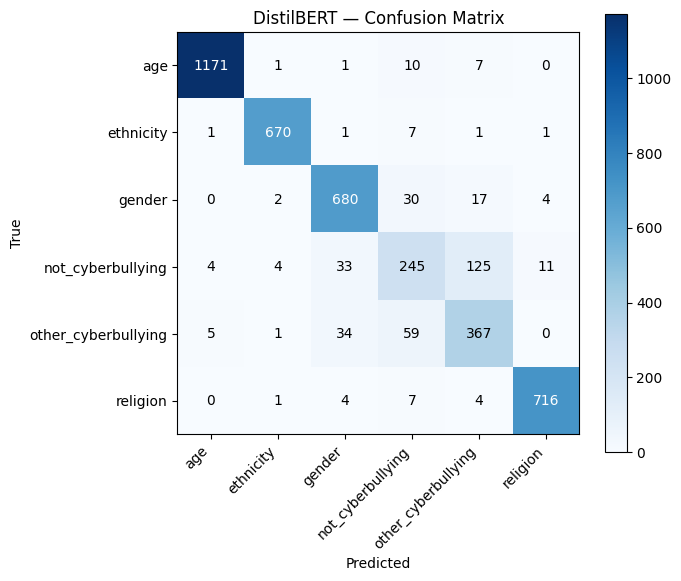

In [13]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_LABELS)); ax.set_xticklabels(target_names, rotation=45, ha='right')
ax.set_yticks(range(NUM_LABELS)); ax.set_yticklabels(target_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('DistilBERT — Confusion Matrix')
thresh = cm.max() / 2
for i in range(NUM_LABELS):
    for j in range(NUM_LABELS):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
fig.colorbar(im); plt.tight_layout(); plt.savefig('transformer_confusion_matrix.png', dpi=110)
plt.show()

In [14]:
results = pd.DataFrame({
    'row_id': test_ds['row_id'],
    'y_true': y_true,
    'y_pred': y_pred,
    'true_label': [id2label[i] for i in y_true],
    'pred_label': [id2label[i] for i in y_pred],
})
results['is_error'] = results['true_label'] != results['pred_label']
results.to_csv('transformer_predictions.csv', index=False)

## 8. Save the model

The fine-tuned model and tokenizer are saved in the native format, and a pickle of the trained
pipeline is exported so it can be reloaded later (e.g. for SHAP-based analysis).

In [15]:
import pickle

model.save_pretrained('./distilbert_cyberbullying_final')
tokenizer.save_pretrained('./distilbert_cyberbullying_final')

with open('DistilBERT.pkl', 'wb') as f:
    pickle.dump({'model': model.cpu(), 'tokenizer': tokenizer,
                 'id2label': id2label, 'label2id': label2id,
                 'max_length': MAX_LENGTH}, f)
print('Saved DistilBERT.pkl and ./distilbert_cyberbullying_final')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 10.34it/s]


Saved DistilBERT.pkl and ./distilbert_cyberbullying_final


## 9. Comparison with the linear/ensemble model

Both models are evaluated on the identical test rows, so per-class and overall scores are directly
comparable.

In [16]:
lin = pd.read_csv(LINEAR_PREDICTIONS_CSV)[['row_id', 'y_pred']].rename(columns={'y_pred': 'lin_pred'})
trf = results[['row_id', 'y_true', 'y_pred']].rename(columns={'y_pred': 'trf_pred'})
merged = trf.merge(lin, on='row_id', how='inner')

def macro(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return accuracy_score(y_true, y_pred), p, r, f1

rows = []
for name, col in [('Linear/Ensemble', 'lin_pred'), ('DistilBERT', 'trf_pred')]:
    acc, p, r, f1 = macro(merged['y_true'], merged[col])
    rows.append({'model': name, 'accuracy': round(acc, 4), 'macro_precision': round(p, 4),
                 'macro_recall': round(r, 4), 'macro_f1': round(f1, 4)})

comparison = pd.DataFrame(rows)
print('Compared on', len(merged), 'shared test rows')
comparison

Compared on 4224 shared test rows


,model,accuracy,macro_precision,macro_recall,macro_f1
0,Linear/Ensemble,0.8911,0.8493,0.8467,0.8458
1,DistilBERT,0.9112,0.8747,0.8736,0.8730
